
# The basic idea

The idea is to modelize the system with 3 compartements : A0 which represents the stomach (we make the approximation that all caffeinated product instantly
gets into the stomach), A1 represents the circulatory system (so blood) and A2 represents the metabolites. 
Only the A1 concentration is plotted, since it's the one that matters the most in term of the project's scope and it's physiological interest. 

We use a simple differential equations system : 
$$
\left\{ \begin{array}{cl}
\frac{dA_{0}}{dt} = -K_{01}A_{0}(t) \\
\frac{dA_{1}}{dt} = K_{01}A_{0}(t) - K_{02}A_{2}(t) \\
\frac{dA_{2}}{dt} = K_{02}A_{2}(t) \\
\end{array} \right.
$$ 


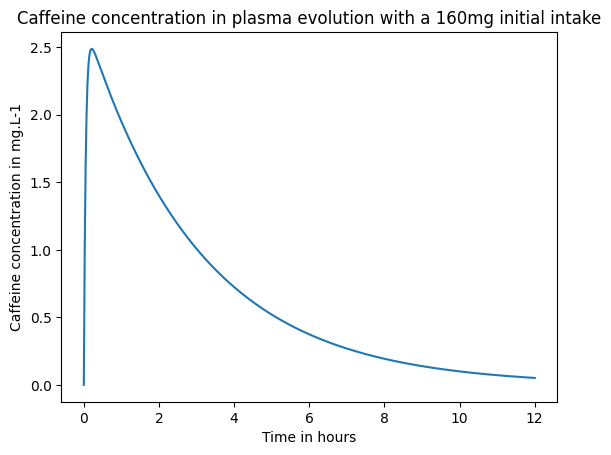

In [4]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import odeint

#We have 3 differential equations, with 2 constants :
#The K01 absorption rate constant : 0.33 min^-1
#The K02 elimination rate constant : 0.33 hour^-1 -> 19.8 min^-1 

K01 = 0.33   #minutes-1 
K02 = 0.33*60   #Minutes-1 
QConso = 160 #Quantity in mg

def model(y,t,K01, K02):
    #Parameters
    A,B,C = y 
    #The kinetics equations 
    dydt = [-K01*A, K01*A - K02*B, K02*B]
    return dydt 

y0 = [QConso, 0, 0]
t=np.linspace(0, 12, 1000)
x = odeint(model, y0, t, args=(K01, K02))

B_plot=[]

for i in range(len(x)):
    B_plot.append(x[i][1])

plt.plot(t, B_plot)
plt.title("Caffeine concentration in plasma evolution with a 160mg initial intake")
plt.ylabel("Caffeine concentration in mg.L-1")
plt.xlabel("Time in hours")
plt.show()

# Bibliography 

- Standing 2016 : https://doi.org/10.1111/bcp.13119
- Willson 2018 : https://doi.org/10.1016/j.toxrep.2018.11.002
- Alsabri 2018 : https://doi.org/10.1089/caff.2017.0011
- Guide to pharmacology : https://www.guidetopharmacology.org/